# Integrative Analysis of Breast Cancer Susceptibility Loci and Tumor Immune Programs Reveals Immune-Associated Candidate Genes in Triple-Negative Breast Cancer

---

## **Notebook 7** - Quantifying Tumor Immune Programs Using Single-Sample Gene Set Enrichment Analysis (ssGSEA)

### Biological objective

Gene-level differential expression identifies transcripts that differ between TNBC and other breast cancer subtypes. However, biological processes are driven by the coordinated activity of many genes rather than isolated transcriptional changes.

In this notebook, we quantify the activity of immune-related biological pathways within each individual breast tumor using Single-Sample Gene Set Enrichment Analysis (ssGSEA).

Unlike conventional GSEA, which compares groups of samples, ssGSEA produces a pathway enrichment score for every patient independently. This enables characterization of inter-patient immune heterogeneity and provides pathway-level phenotypes for downstream analyses.

The resulting immune enrichment matrix will later be integrated with prioritized susceptibility genes to investigate whether inherited breast cancer risk genes are associated with tumor immune programs in Triple-Negative Breast Cancer.

In [1]:
import numpy as np
import pandas as pd
import gseapy as gp
import matplotlib.pyplot as plt
import seaborn as sns

### 1. Load Processed RNA-seq Data

In [2]:
counts = pd.read_csv("../data/rna_seq/brca_counts_cleaned.csv", index_col=0)

In [3]:
print(f"Initial raw matrix dimensions: {counts.shape}")

Initial raw matrix dimensions: (19969, 725)


### 2. Normalize Gene Expression

Raw RNA-seq counts cannot be compared directly across patients because sequencing depth differs between samples.

To reduce these technical differences, expression values are normalized using:

- Counts Per Million (CPM)
- log2(CPM + 1) transformation

In [4]:
cpm = counts.div(counts.sum(axis=0), axis=1) * 1e6
counts_log2_cpm = np.log2(cpm + 1)

### 3. Resolve Duplicate Gene Symbols

Some genes appear multiple times because multiple Ensembl identifiers can map to the same gene symbol.

Since ssGSEA requires unique gene identifiers, duplicate entries are collapsed by averaging their normalized expression profiles.

This produces a non-redundant expression matrix suitable for pathway analysis.

In [5]:
if counts_log2_cpm.index.duplicated().any():
    print(f"Found {counts_log2_cpm.index.duplicated().sum()} duplicate genes in CPM matrix. Averaging profiles...")
    
    counts_log2_cpm = counts_log2_cpm.groupby(level=0).mean()

Found 31 duplicate genes in CPM matrix. Averaging profiles...


### 4. Calculate Patient-Specific Pathway Activity

Single-Sample Gene Set Enrichment Analysis (ssGSEA) estimates the relative activity of predefined biological pathways within each individual tumor.

Unlike differential expression analysis, which compares groups of patients, ssGSEA generates enrichment scores independently for every sample.

Pathway definitions are obtained from the **MSigDB Hallmark** collection, a curated resource that summarizes major biological processes while reducing redundancy among gene sets.

In [6]:
ssgsea_res = gp.ssgsea(
    data=counts_log2_cpm,
    gene_sets='MSigDB_Hallmark_2020',
    outdir=None,
    sample_norm_method='rank',  
    permutation_num=0,          
    no_plot=True
)

ssgsea_df = ssgsea_res.res2d

### 5. Select Immune-Related Hallmark Signatures

This study focuses specifically on immune programs that are highly relevant to tumor biology and the immune microenvironment.

Six Hallmark pathways were selected:

- Interferon Gamma Response
- Interferon Alpha Response
- Complement
- TNF-α Signaling via NF-κB
- IL6/JAK/STAT3 Signaling
- Inflammatory Response

Together, these pathways capture major components of innate immunity, adaptive immunity, inflammatory signaling, cytokine responses, and immune activation within breast tumors.

In [7]:
ssgsea_df['Term'].unique()

array(['Myc Targets V1', 'Interferon Alpha Response',
       'Epithelial Mesenchymal Transition', 'Protein Secretion',
       'Oxidative Phosphorylation', 'E2F Targets', 'TGF-beta Signaling',
       'Myc Targets V2', 'mTORC1 Signaling', 'G2-M Checkpoint',
       'Unfolded Protein Response', 'Androgen Response',
       'Interferon Gamma Response', 'Reactive Oxygen Species Pathway',
       'Estrogen Response Early', 'Mitotic Spindle',
       'TNF-alpha Signaling via NF-kB', 'Cholesterol Homeostasis',
       'UV Response Dn', 'Adipogenesis', 'Angiogenesis', 'Apoptosis',
       'Notch Signaling', 'Estrogen Response Late',
       'PI3K/AKT/mTOR  Signaling', 'DNA Repair', 'Allograft Rejection',
       'Hypoxia', 'p53 Pathway', 'Glycolysis', 'UV Response Up',
       'IL-6/JAK/STAT3 Signaling', 'Complement',
       'Wnt-beta Catenin Signaling', 'Apical Junction', 'Pperoxisome',
       'Fatty Acid Metabolism', 'IL-2/STAT5 Signaling',
       'Hedgehog Signaling', 'Myogenesis', 'heme Metabolism',

In [8]:
immune_hallmarks = [
    'Interferon Gamma Response',
    'Interferon Alpha Response',
    'Complement',
    'TNF-alpha Signaling via NF-kB',
    'IL-6/JAK/STAT3 Signaling',
    'Inflammatory Response'
]

### 6. Extract Immune Pathway Enrichment Scores

The complete ssGSEA output contains enrichment scores for all Hallmark pathways.

Here, the analysis is restricted to the predefined immune-related signatures to generate a focused immune activity matrix for downstream analyses.

In [9]:
filtered_ssgsea = ssgsea_df[ssgsea_df['Term'].isin(immune_hallmarks)].copy()

In [10]:
filtered_ssgsea 

,Name,Term,ES,NES
99,TCGA-EW-A1PB,Interferon Alpha Response,7683.371554,0.716206
153,TCGA-BH-A0BW,Interferon Alpha Response,7540.358565,0.702875
158,TCGA-AR-A1AJ,Interferon Alpha Response,7534.941486,0.70237
160,TCGA-A2-A4S2,Interferon Alpha Response,7533.9266,0.702275
164,TCGA-C8-A12V,Interferon Alpha Response,7525.475074,0.701487
...,...,...,...,...
35923,TCGA-E9-A54X,Inflammatory Response,386.632595,0.03604
36046,TCGA-AN-A04D,Inflammatory Response,260.02634,0.024238
36054,TCGA-EW-A1OX,Inflammatory Response,253.595564,0.023639
36157,TCGA-A1-A0SK,Inflammatory Response,113.374121,0.010568


### 7. Construct Patient-Level Immune Activity Matrix

The enrichment results are reshaped into a matrix where:

- rows represent individual patients
- columns represent immune Hallmark pathways
- values represent ssGSEA enrichment scores

This matrix summarizes immune pathway activity across the entire breast cancer cohort and serves as a pathway-level representation of each tumor.

In [11]:
ssgsea_scores = filtered_ssgsea.pivot(
    index='Name',      
    columns='Term',    
    values='ES'       
)
ssgsea_scores.index.name = "patient_id"

In [12]:
print(f"ssGSEA matrix generated successfully: {ssgsea_scores.shape}")

ssGSEA matrix generated successfully: (725, 6)


### 8. Validation Analysis: Immune Pathway Co-Regulation

Immune pathways rarely function independently.

To evaluate whether the selected Hallmark signatures capture coordinated biological processes, pairwise Spearman rank correlations are calculated between all immune pathways.

Positive correlations indicate pathways that tend to be activated together across patients, reflecting coordinated immune regulation within the tumor microenvironment.

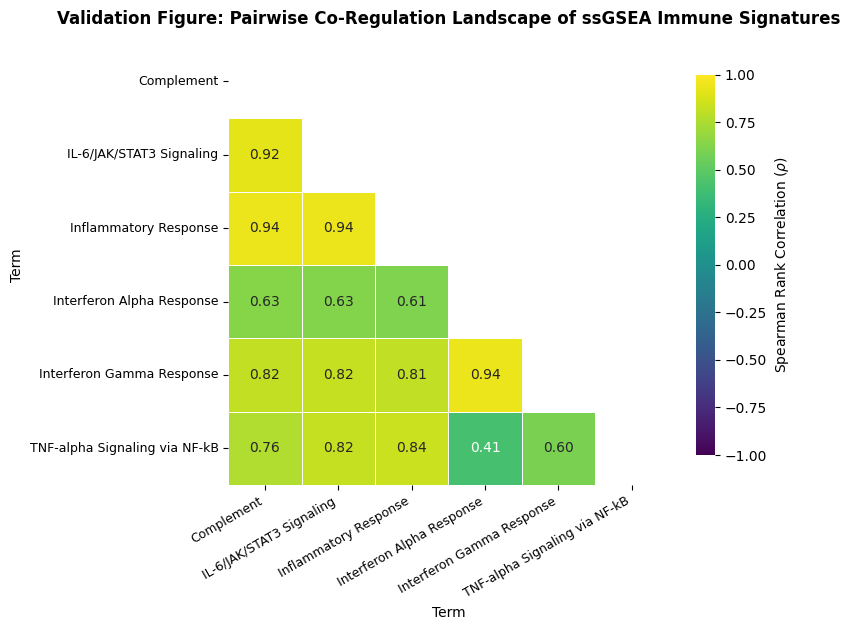

In [13]:
pathway_corr_matrix = ssgsea_scores.corr(method='spearman')

mask = np.triu(np.ones_like(pathway_corr_matrix, dtype=bool))

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    pathway_corr_matrix,
    mask=mask,
    cmap='viridis',  
    vmax=1.0, vmin=-1.0, center=0,
    annot=True, fmt=".2f",
    square=True, linewidths=.5,
    cbar_kws={"shrink": .7, "label": "Spearman Rank Correlation ($\\rho$)"},
    ax=ax
)

ax.set_title('Validation Figure: Pairwise Co-Regulation Landscape of ssGSEA Immune Signatures', fontsize=12, fontweight='bold', pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=30, ha='right', fontsize=9)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=9)

plt.tight_layout()
plt.savefig('../results/figures/pathway_co_regulation_heatmap.png', dpi=300, bbox_inches='tight')

### Biological Interpretation

Strong positive correlations are observed among multiple immune pathways.

Notably,

- Complement,
- IL6/JAK/STAT3 Signaling,
- Inflammatory Response,

form a tightly coordinated inflammatory module.

Similarly,

- Interferon-α Response
- Interferon-γ Response

show exceptionally strong co-regulation, consistent with their shared roles in antiviral defense, cytokine signaling, and anti-tumor immunity.

These relationships support the biological consistency of the ssGSEA-derived immune signatures and indicate that the selected pathways capture coherent immune processes rather than unrelated transcriptional events.

### 9. Export Immune Signature Matrix

The finalized immune enrichment matrix is saved for downstream analyses.

This dataset will be used to:

- compare immune pathway activity between molecular subtypes,
- investigate relationships between prioritized GWAS candidate genes and immune signaling,
- support integrative analyses linking inherited susceptibility with tumor immune phenotypes.

In [14]:
ssgsea_scores.to_csv("../results/tables/brca_ssgsea_immune_scores.csv")

### Notebook Summary

In this notebook, patient-specific immune pathway activity was quantified using **Single-Sample Gene Set Enrichment Analysis (ssGSEA)**.

Major accomplishments include:

- normalized RNA-seq expression using log2 CPM,
- resolved duplicate gene symbols,
- computed ssGSEA enrichment scores across MSigDB Hallmark pathways,
- extracted six biologically relevant immune signatures,
- generated a patient-by-pathway immune activity matrix for 710 TCGA-BRCA tumors,
- evaluation of pathway co-regulation through Spearman correlation analysis.

Unlike differential expression analysis, which identifies genes altered between groups, ssGSEA characterizes the activity of coordinated biological pathways within individual tumors.

The immune enrichment matrix generated here provides the foundation for subsequent analyses investigating how inherited breast cancer susceptibility genes relate to variation in immune signaling across Triple-Negative Breast Cancer.